# DATA

In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = pd.read_csv(r'C:\Code_AI\AIO_Code\Module2\DiamondPredict\diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [23]:
data = data.drop(['Unnamed: 0'], axis = 1)
data.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [24]:
# 1. CUT: Fair < Good < Very Good < Premium < Ideal
cut_mapping = {
    'Fair': 0,
    'Good': 1,
    'Very Good': 2,
    'Premium': 3,
    'Ideal': 4
}
data['cut'] = data['cut'].map(cut_mapping)

# 2. COLOR: J < I < H < G < F < E < D 
color_mapping = {
    'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6
}
data['color'] = data['color'].map(color_mapping)

# 3. CLARITY: I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF
clarity_mapping = {
    'I1': 0, 
    'SI2': 1, 'SI1': 2, 
    'VS2': 3, 'VS1': 4, 
    'VVS2': 5, 'VVS1': 6, 
    'IF': 7
}
data['clarity'] = data['clarity'].map(clarity_mapping)

In [25]:
data.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75


TRAINING, TESTING

In [26]:
X = data.drop(['price'], axis = 1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()
X_test = X_test.to_numpy()
y_test = y_test.to_numpy()

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit(X_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (43152, 9)
y_train shape: (43152,)


In [ ]:
n, m = X_train.shape
X_train_b = np.c_[np.ones(n), X_train]
theta = np.zeros(m + 1)

(10,)


In [33]:
print(X_train_b.shape)
print(y_train.shape)
print(theta.shape)

(43152, 10)
(43152,)
(10,)


In [34]:
def predict(X_train, theta):
    return X_train.dot(theta)
def computeGradients(X_train, y_train, theta):
    batch_size = len(y_train)
    y_hat = predict(X_train, theta)
    error = y_hat - y_train
    dtheta = (2/batch_size) * X_train.T.dot(error)
    return dtheta
def computeLoss(X_train, y_train, theta):
    n = len(y_train)
    y_hat = predict(X_train, theta)
    return (1/n) * np.sum((y_hat - y_train)**2)

Epoch 0: Loss = 1476568.04
Epoch 100: Loss = 1475198.88
Epoch 200: Loss = 1475193.07
Epoch 300: Loss = 1475191.64
Epoch 400: Loss = 1475191.32
Epoch 500: Loss = 1475191.17
Epoch 600: Loss = 1475191.21
Epoch 700: Loss = 1475191.51
Epoch 800: Loss = 1475191.30
Epoch 900: Loss = 1475191.16
---------------------------------
Huấn luyện xong!
Loss cuối cùng: 1475191.37


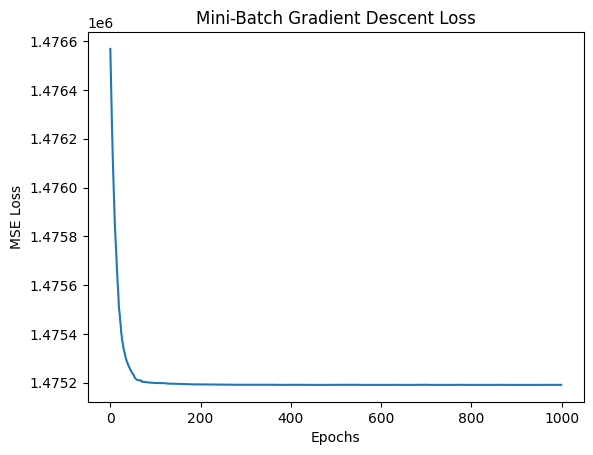

In [40]:
learning_rate = 0.0001
batch_size = 1000
epochs = 1000
loss_history = []

for epoch in range(epochs):
    indices = np.random.permutation(n)
    X_train_shuffled = X_train_b[indices]
    y_train_shuffled = y_train[indices]

    for i in range(0, n, batch_size):
        xi = X_train_shuffled[i:i+batch_size]
        yi = y_train_shuffled[i:i+batch_size]

        grads = computeGradients(xi, yi, theta)
        theta = theta - learning_rate * grads
    total_loss = computeLoss(X_train_b, y_train, theta)
    loss_history.append(total_loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss:.2f}")

print("---------------------------------")
print("Huấn luyện xong!")
print(f"Loss cuối cùng: {loss_history[-1]:.2f}")

# 5. Vẽ biểu đồ
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Mini-Batch Gradient Descent Loss')
plt.show()


In [41]:
mse_final = loss_history[-1]
rmse_final = np.sqrt(mse_final)

print(f"MSE (Bình phương lỗi): {mse_final:.2f}")
print(f"RMSE (Sai số trung bình theo USD): {rmse_final:.2f} USD")

MSE (Bình phương lỗi): 1475191.37
RMSE (Sai số trung bình theo USD): 1214.57 USD


In [42]:
import numpy as np
import joblib

# 1. Lưu bộ trọng số theta (đang là numpy array)
np.save('my_diamond_theta.npy', theta)

# 2. Lưu bộ chuẩn hóa Scaler
joblib.dump(scaler, 'my_scaler.pkl')

print("Đã lưu xong! Bạn hãy tìm 2 file .npy và .pkl trong thư mục.")

Đã lưu xong! Bạn hãy tìm 2 file .npy và .pkl trong thư mục.


In [43]:
print(X.columns)

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z'], dtype='object')
